<a href="https://colab.research.google.com/github/JalalMominAfridi/JalalMominAfridi/blob/main/Invoice_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
df.duplicated(subset=["invoice_id"]).sum()

np.int64(0)

In [14]:
import pandas as pd
import numpy as np
import random

random.seed(42)
np.random.seed(42)

n = 500
vendors = ["Alpha Supplies", "Beta Motors", "Gamma Parts", "Delta Tools", "Omega Trading"]

df = pd.DataFrame({
    "invoice_id": [f"INV{1000+i}" for i in range(n)],
    "vendor": np.random.choice(vendors, n),
    "date": pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, n), unit="D"),
    "amount": np.round(np.random.normal(5000, 1500, n), 2),
})

# add duplicates and outliers on purpose
dupes = df.sample(15)
df = pd.concat([df, dupes], ignore_index=True)
df.loc[df.sample(8).index, "amount"] *= 6

df.to_csv("invoices.csv", index=False)
df.head()

,invoice_id,vendor,date,amount
0,INV1000,Delta Tools,2024-03-02,6577.39
1,INV1001,Omega Trading,2024-03-24,3734.68
2,INV1002,Gamma Parts,2024-08-04,2629.62
3,INV1003,Omega Trading,2024-12-07,5024.08
4,INV1004,Omega Trading,2024-07-05,4641.23


In [15]:
print("Rows:", len(df))
print("Duplicate invoices:", df.duplicated(subset="invoice_id").sum())
df = df.drop_duplicates(subset="invoice_id")
print("Rows after cleaning:", len(df))

Rows: 515
Duplicate invoices: 15
Rows after cleaning: 500


In [16]:
print("Rows:", len(df))
print("Duplicate invoices:", df.duplicated(subset="invoice_id").sum())
df = df.drop_duplicates(subset="invoice_id")
print("Rows after cleaning:", len(df))
mean, std = df["amount"].mean(), df["amount"].std()
df["anomaly"] = (df["amount"] - mean).abs() > 3 * std
print("Anomalies found:", df["anomaly"].sum())
df[df["anomaly"]]

Rows: 500
Duplicate invoices: 0
Rows after cleaning: 500
Anomalies found: 8


,invoice_id,vendor,date,amount,anomaly
24,INV1024,Alpha Supplies,2024-02-08,26872.26,True
26,INV1026,Gamma Parts,2024-06-29,41582.76,True
279,INV1279,Gamma Parts,2024-02-20,35254.20,True
316,INV1316,Gamma Parts,2024-12-20,33764.28,True
358,INV1358,Alpha Supplies,2024-03-08,27998.28,True
373,INV1373,Gamma Parts,2024-01-06,29739.66,True
419,INV1419,Delta Tools,2024-05-12,23413.08,True
472,INV1472,Beta Motors,2024-12-14,33614.64,True


<Axes: title={'center': 'Total spend by vendor'}, ylabel='vendor'>

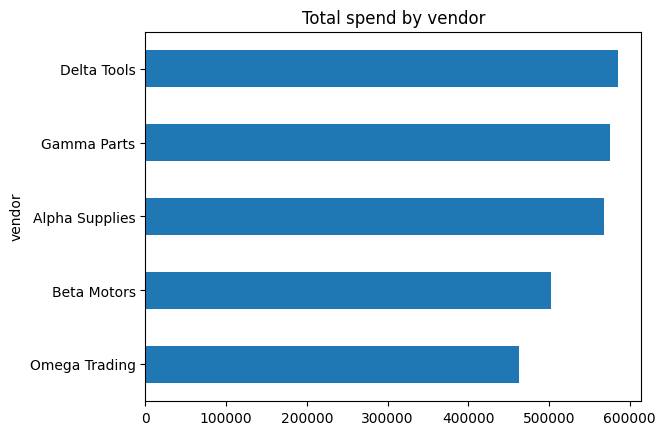

In [17]:
df.groupby("vendor")["amount"].sum().sort_values().plot(kind="barh", title="Total spend by vendor")


<Axes: title={'center': 'Monthly spend'}, xlabel='date'>

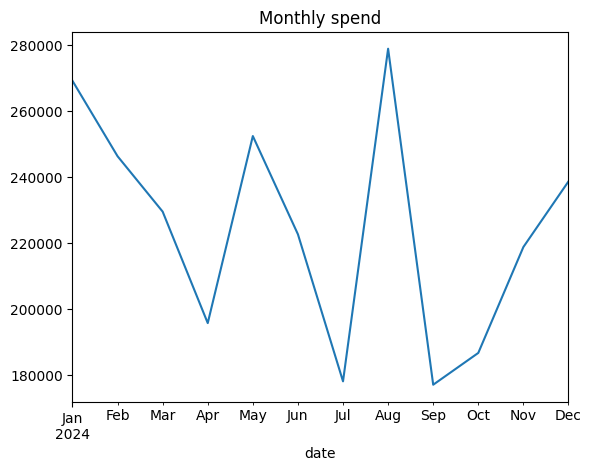

In [18]:
df.groupby(df["date"].dt.to_period("M"))["amount"].sum().plot(title="Monthly spend")

# Invoice Analysis: Findings

## Summary
I analyzed 515 invoices across 5 vendors for 2024 to find duplicates and unusual amounts.

## Findings
- **Duplicates:** 15 invoices appeared twice and were removed, leaving 500 unique invoices.
- **Anomalies:** [X] invoices were more than 3 standard deviations above the average amount.
- **Spend by vendor:** [vendor name] had the highest total spend, and [vendor name] the lowest.
- **Monthly trend:** Spend was highest in [month] and lowest in [month].

## Recommendations
1. Add an automatic duplicate check on invoice ID before payment is approved.
2. Require manual review for any invoice above [amount] (the anomaly threshold).
3. Review the flagged vendors' pricing against purchase orders.

## Method
Python (pandas) for cleaning and analysis. Anomalies were flagged with a 3-standard-deviation rule.